In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
dataframe = pd.read_csv('/content/diabetes.csv')

In [8]:
dataframe.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### Data Imputation: Handling Zero Values

Some features in the dataset, such as 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI', have zero values that are biologically implausible and represent missing data. We will impute these zeros using appropriate strategies (mean or median) based on the distribution of each feature.

In [9]:
dataframe.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [10]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [67]:
# Check for explicit null values (NaNs). Note: This does not detect 0s that represent missing data.
dataframe.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
dataframe.shape

(768, 9)

target column : Outcome[0,1]
as the target is avialle so supervised algo

In [13]:
corr = dataframe.corr()

In [14]:
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


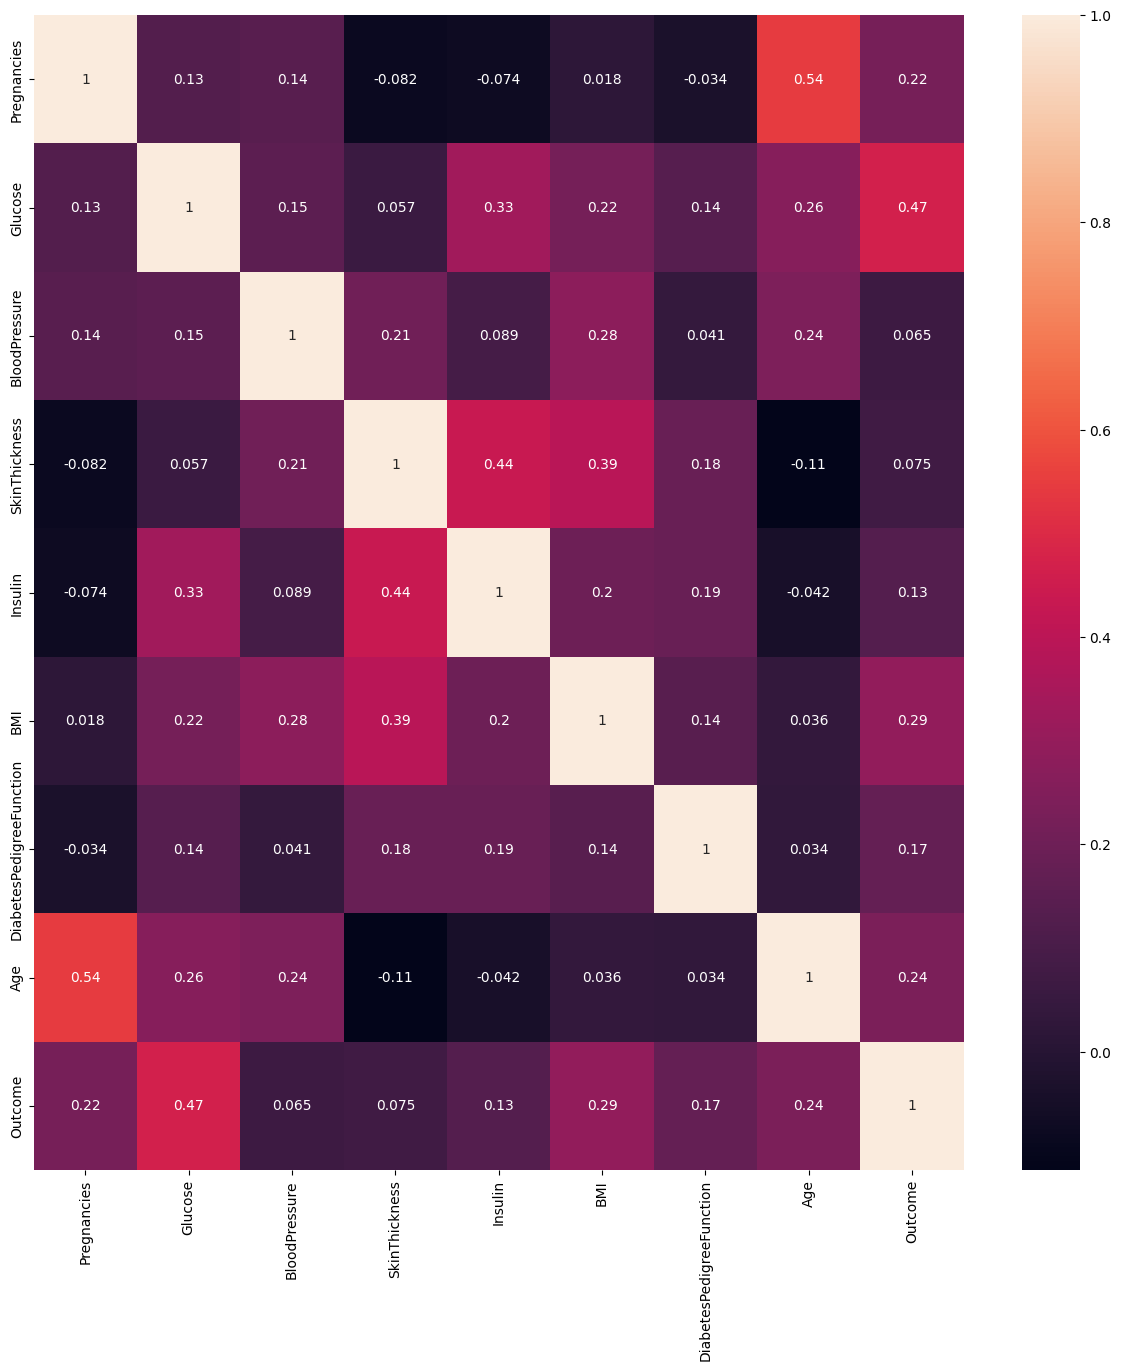

In [15]:
plt.figure(figsize=(15,15))
ax = sns.heatmap(dataframe.corr(), annot=True)
plt.savefig('correlation-coefficient.jpg')
plt.show()

### Descriptive Statistics: An overview of the dataset's central tendency, dispersion, and shape.

In [16]:
dataframe.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Data Imputation

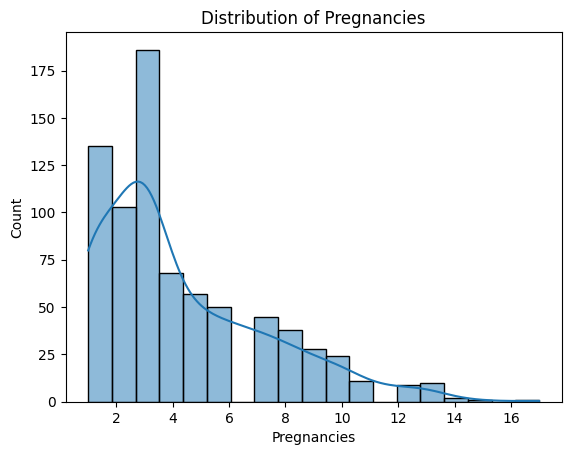

In [64]:
# Visualize the distribution of 'Pregnancies'. This helps decide the imputation strategy.
sns.histplot(dataframe.Pregnancies, kde=True)
plt.title('Distribution of Pregnancies')
plt.show()

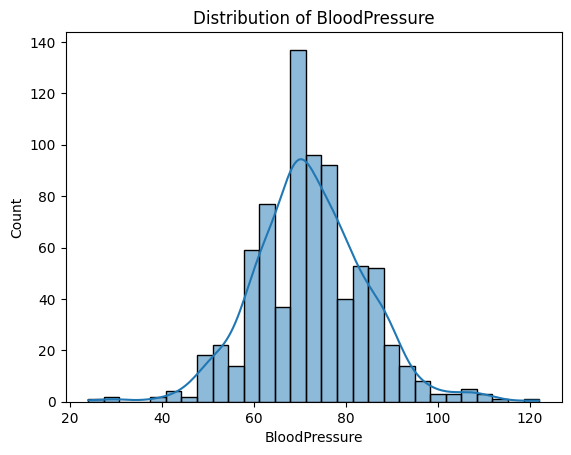

In [65]:
# Visualize the distribution of 'BloodPressure'. This helps decide the imputation strategy.
sns.histplot(dataframe.BloodPressure, kde=True)
plt.title('Distribution of BloodPressure')
plt.show()

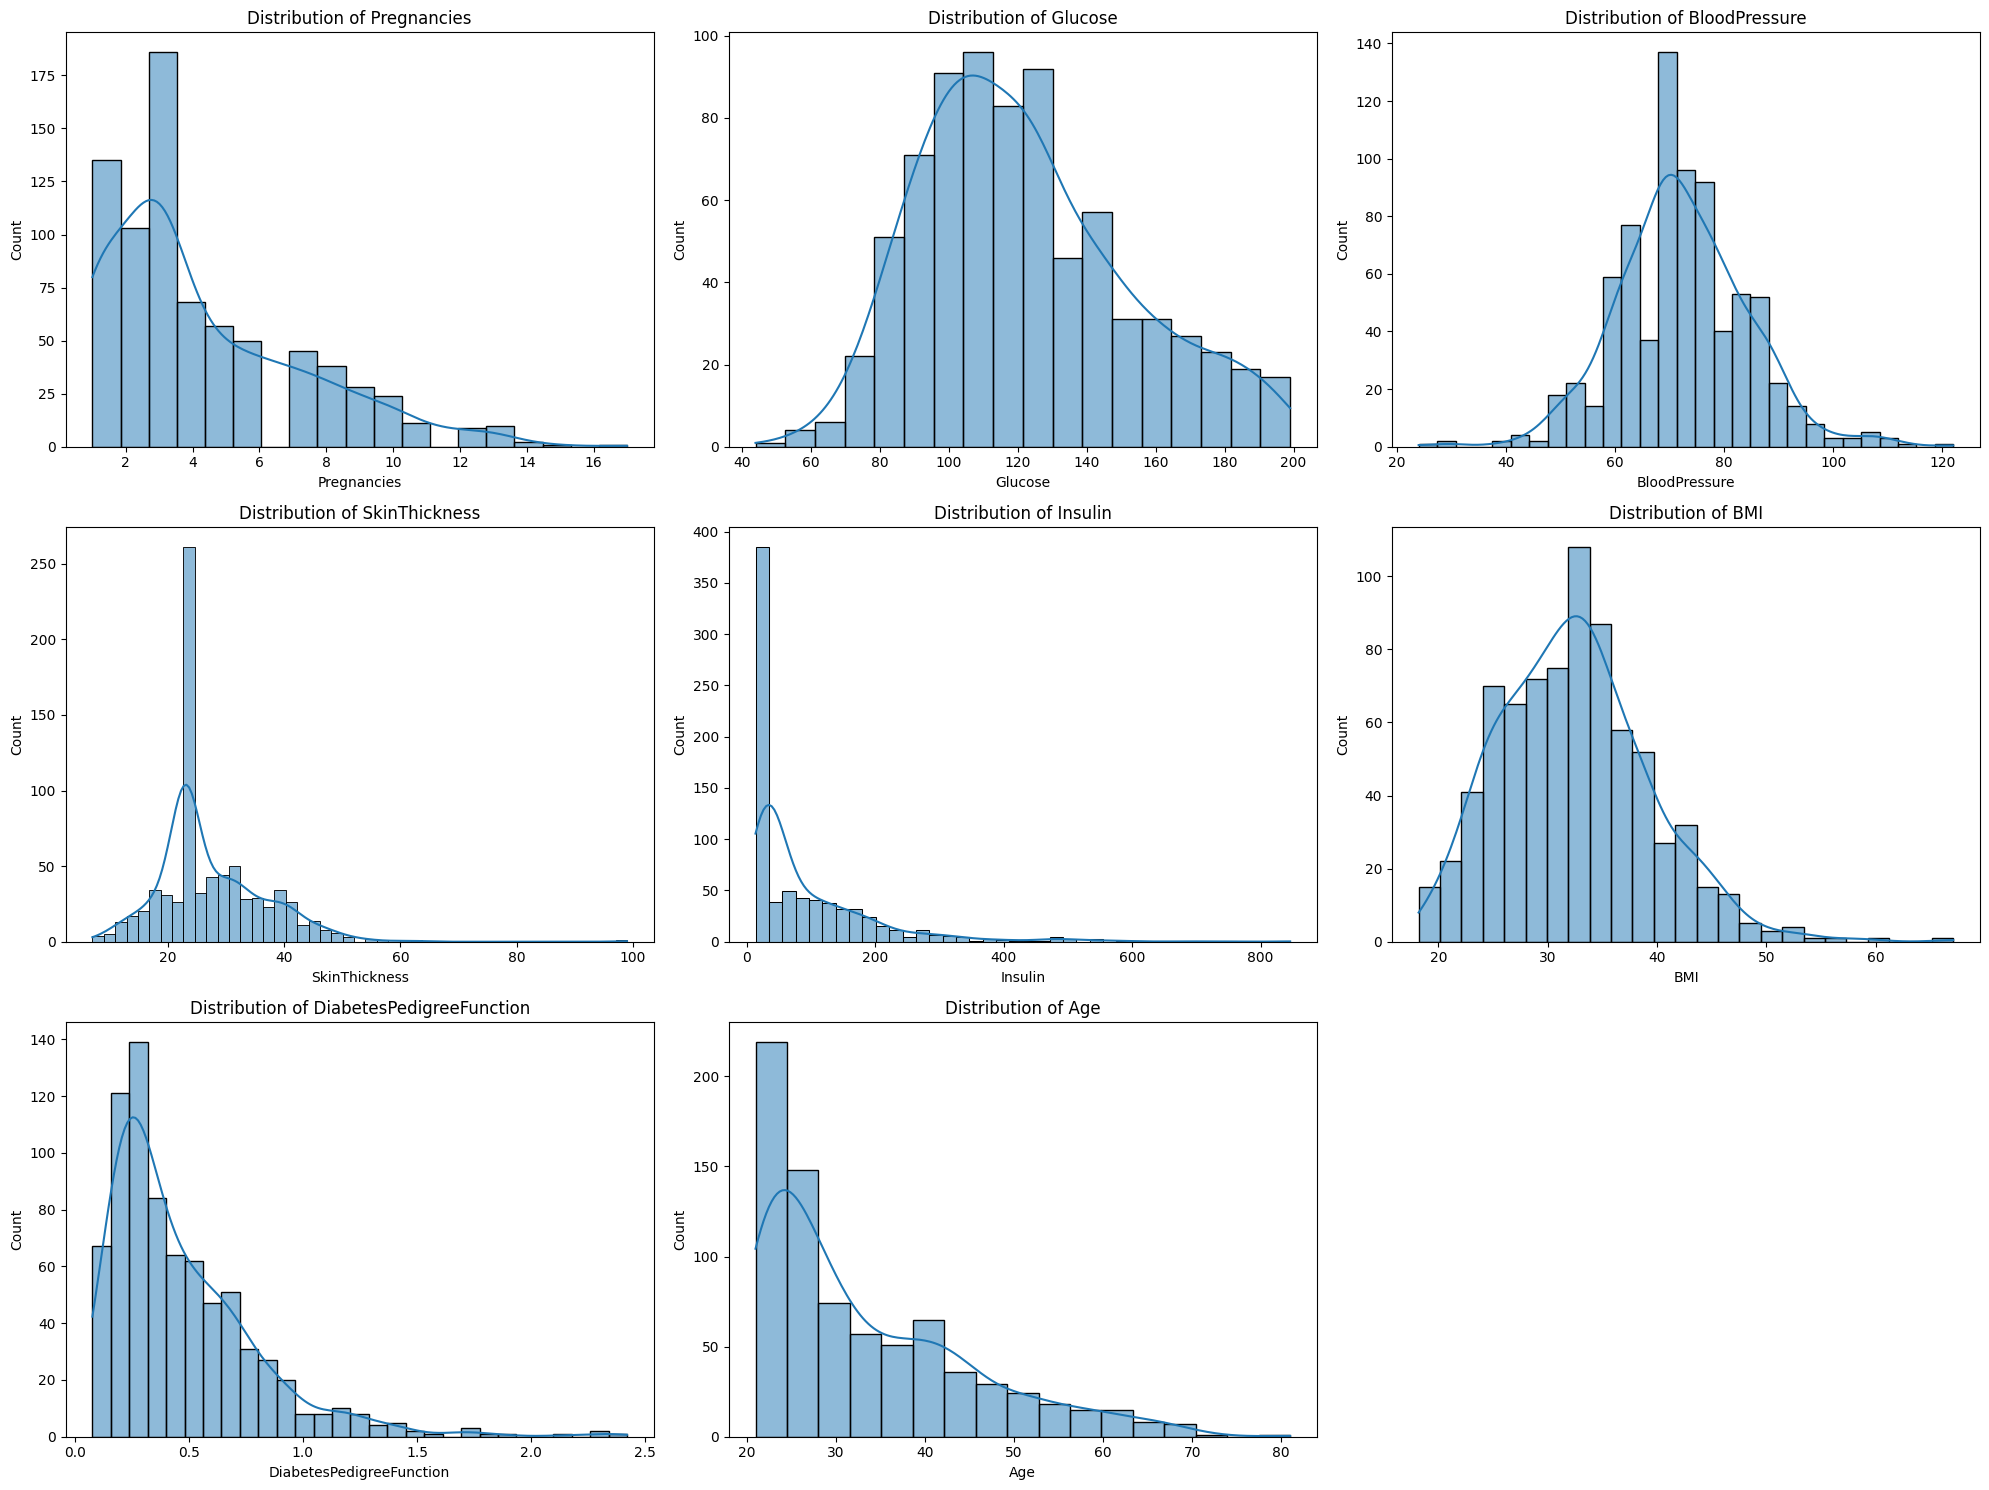

In [66]:
columns_to_plot = dataframe.columns.drop('Outcome')

plt.figure(figsize=(20, 15))
for i, col in enumerate(columns_to_plot):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(dataframe[col], kde=True) # Using histplot as distplot is deprecated
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [68]:
## Insulin Imputation: Right-Skewed Distribution
# For 'Insulin', which shows a right-skewed distribution (as seen in the histograms), the median is a more robust measure than the mean for imputation, as it is less affected by extreme values.
dataframe['Insulin'] = dataframe['Insulin'].replace(0, dataframe['Insulin'].median())

In [69]:
# Imputing 0 values with appropriate measures based on distribution:
# For 'Pregnancies', replace 0s with the median.
dataframe['Pregnancies'] = dataframe['Pregnancies'].replace(0, dataframe['Pregnancies'].median())
# For 'Glucose' and 'BloodPressure', which might be more symmetrically distributed after initial inspection or subject knowledge, replace 0s with the mean.
dataframe['Glucose'] = dataframe['Glucose'].replace(0, dataframe['Glucose'].mean())
dataframe['BloodPressure'] = dataframe['BloodPressure'].replace(0, dataframe['BloodPressure'].mean())
# For 'SkinThickness', which is often skewed, replace 0s with the median.
dataframe['SkinThickness'] = dataframe['SkinThickness'].replace(0, dataframe['SkinThickness'].median())
# For 'BMI', often approximately normal, replace 0s with the mean.
dataframe['BMI'] = dataframe['BMI'].replace(0, dataframe['BMI'].mean())
# 'DiabetesPedigreeFunction' and 'Age' are generally not expected to have 0s as missing values, but if found, impute with median/mean based on distribution.
dataframe['DiabetesPedigreeFunction'] = dataframe['DiabetesPedigreeFunction'].replace(0, dataframe['DiabetesPedigreeFunction'].median())
dataframe['Age'] = dataframe['Age'].replace(0, dataframe['Age'].median())

In [22]:
dataframe.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.000000,35,30.5,33.600000,0.627,50,1
1,1,85.0,66.000000,29,30.5,26.600000,0.351,31,0
2,8,183.0,64.000000,23,30.5,23.300000,0.672,32,1
3,1,89.0,66.000000,23,94.0,28.100000,0.167,21,0
4,3,137.0,40.000000,35,168.0,43.100000,2.288,33,1
5,5,116.0,74.000000,23,30.5,25.600000,0.201,30,0
6,3,78.0,50.000000,32,88.0,31.000000,0.248,26,1
7,10,115.0,69.105469,23,30.5,35.300000,0.134,29,0
8,2,197.0,70.000000,45,543.0,30.500000,0.158,53,1
9,8,125.0,96.000000,23,30.5,31.992578,0.232,54,1


### Key Concepts and Best Practices:

*   **Descriptive Statistics**: Understanding the central tendency, dispersion, and shape of your data is crucial for initial insights.
*   **Correlation Coefficient**: Measures the linear relationship between variables, indicating strength and direction.
*   **Types of Distribution**: Visualizing data distribution (e.g., normal, skewed) helps in choosing appropriate statistical methods and imputation strategies.
*   **Median vs. Mean for Imputation**: The median is generally more robust to outliers and skewed distributions, making it a preferred choice for imputation in such cases, while the mean is suitable for symmetrically distributed data.
*   **Data Imputation**: Addressing missing values (often represented as 0s in this dataset for certain features) by replacing them with calculated values (mean or median for numerical, mode for categorical) to maintain dataset integrity.

In [23]:
## X -> input features y -> target value
X = dataframe.drop(columns='Outcome', axis=1)
y = dataframe['Outcome']


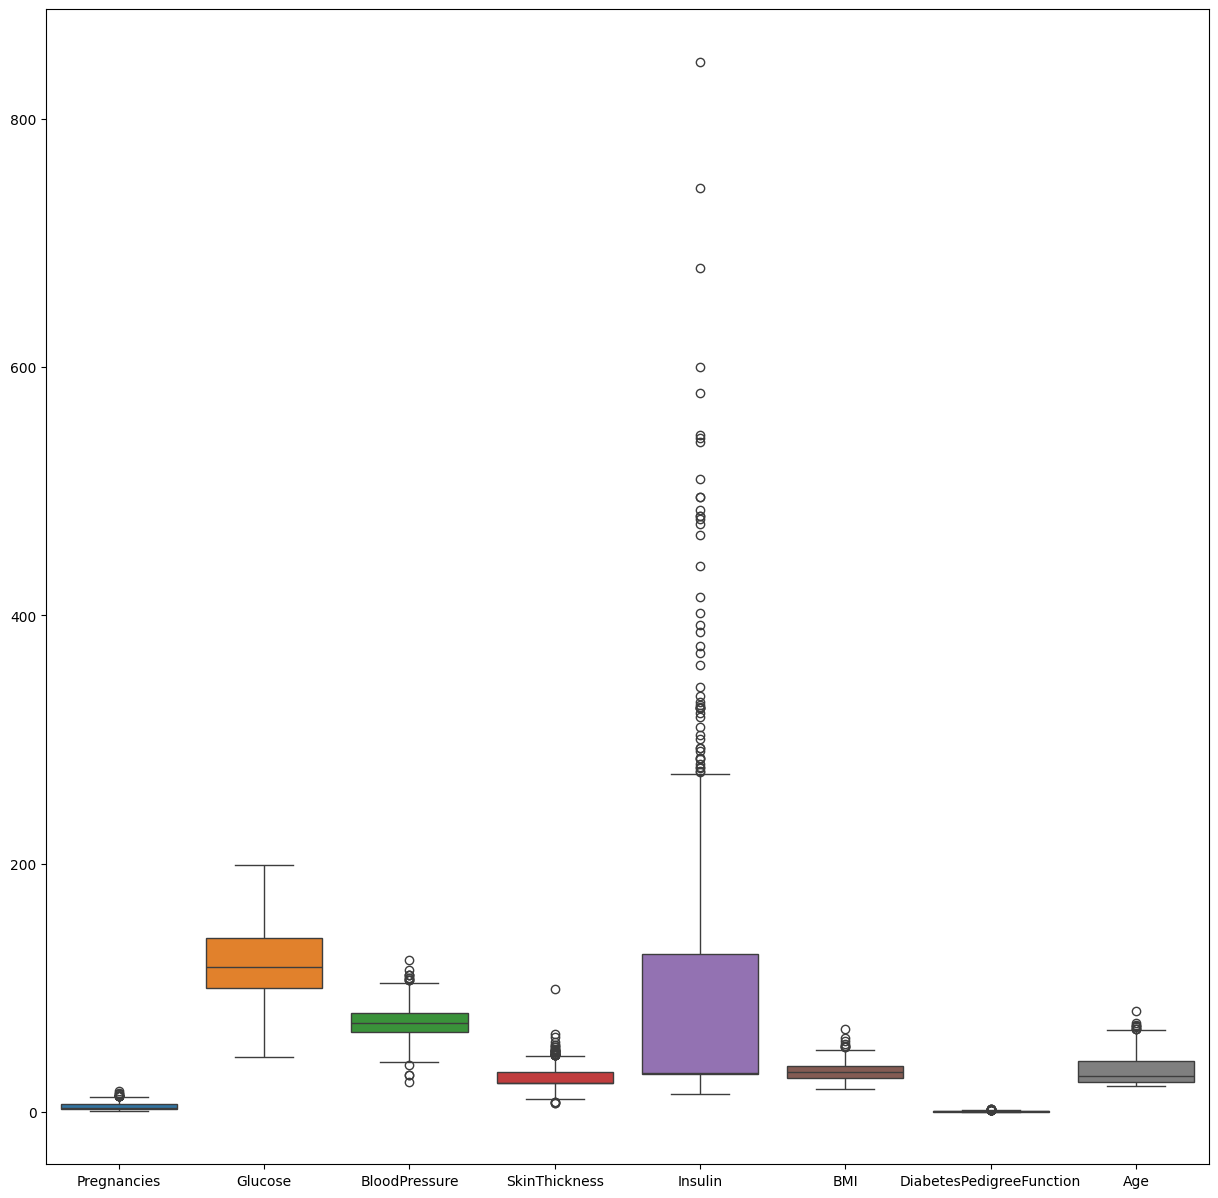

In [24]:
fig, ax = plt.subplots(figsize = (15, 15))
sns.boxplot(data = X, ax=ax)
plt.savefig('boxPlot.jpg')

In [70]:
# Removing outliers for all required columns using the IQR method.
# The IQR (Interquartile Range) method identifies outliers as data points that fall below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X_outlier_detection=X
y_outlier_detection=y
for col in cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (X[col] >= lower_bound) & (X[col] <= upper_bound)
    X_outlier_detection_total = X_outlier_detection[mask]
    y_outlier_detection_total= y_outlier_detection[mask]
    # Print the count of True (non-outliers) and False (outliers) for each column
    for idx, name in enumerate(mask.value_counts().index.tolist()):
     print(f"for {col},{name}->{mask.value_counts()[idx]}")

for Pregnancies,True->754
for Pregnancies,False->14
for Glucose,True->768
for BloodPressure,True->754
for BloodPressure,False->14
for SkinThickness,True->733
for SkinThickness,False->35
for Insulin,True->719
for Insulin,False->49
for BMI,True->760
for BMI,False->8
for DiabetesPedigreeFunction,True->739
for DiabetesPedigreeFunction,False->29
for Age,True->759
for Age,False->9


/tmp/ipykernel_26427/3726872070.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"for {col},{name}->{mask.value_counts()[idx]}")
/tmp/ipykernel_26427/3726872070.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"for {col},{name}->{mask.value_counts()[idx]}")
/tmp/ipykernel_26427/3726872070.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"for {col},{name}->{mask.value_counts()[idx]}")
/tmp/ipykernel_2

In [80]:
# Feature Scaling: Applying StandardScaler
# StandardScaler transforms features to have a mean of 0 and a standard deviation of 1. This is crucial for many machine learning algorithms (like KNN and Logistic Regression) that are sensitive to the scale of input features, preventing features with larger numerical ranges from disproportionately influencing the model.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_outlier_detection)
X_scaled = pd.DataFrame(X_scaled_array, columns=cols)

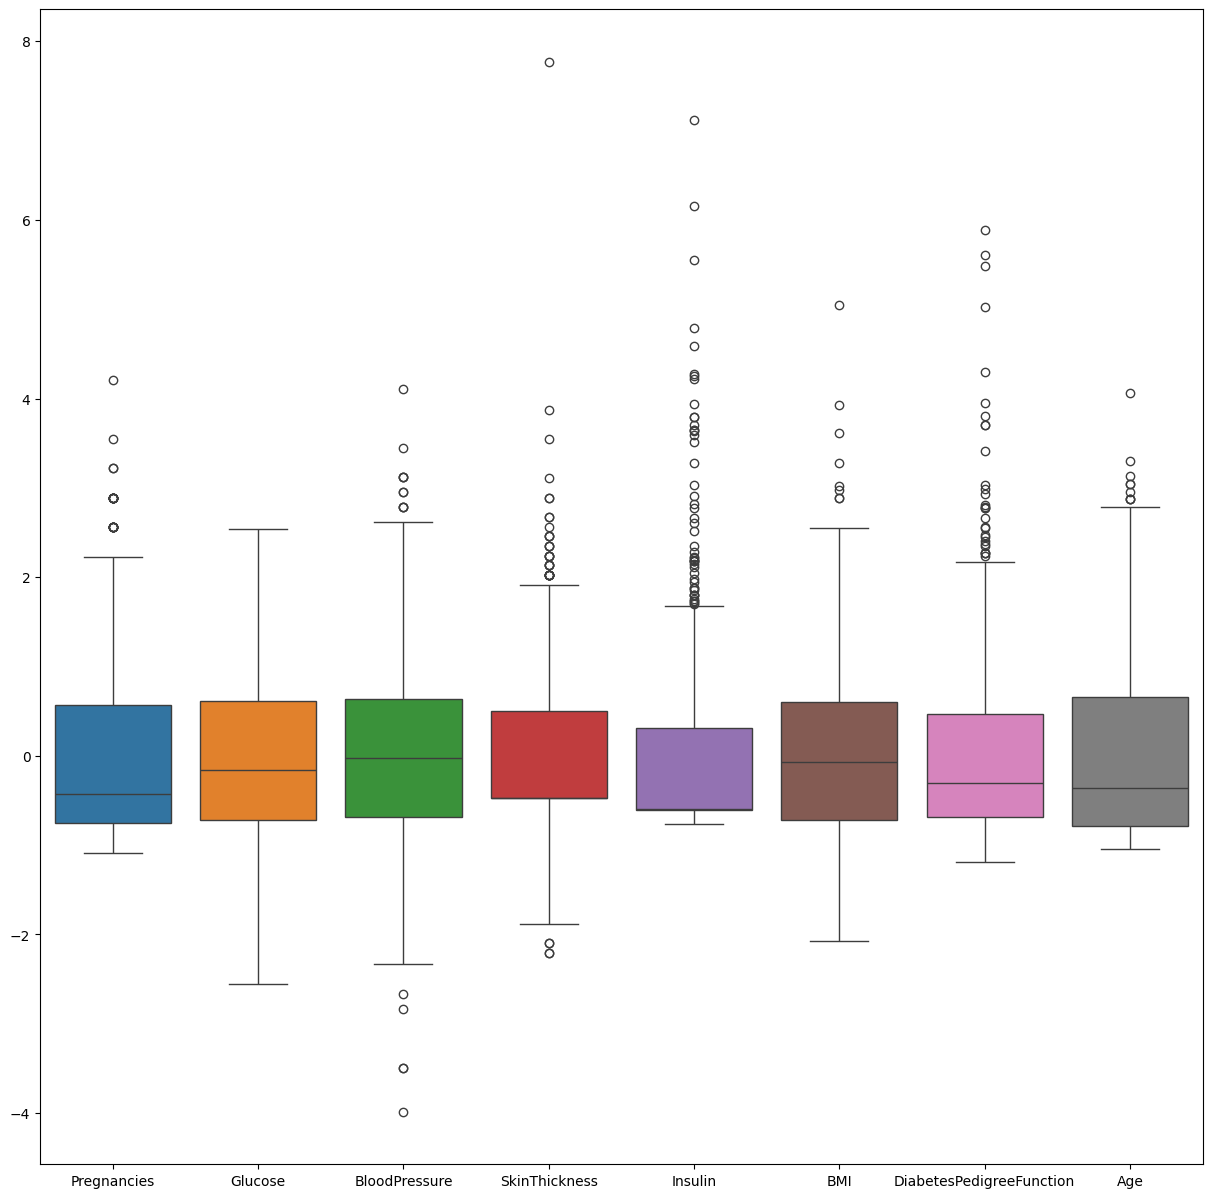

In [102]:
fig, ax = plt.subplots(figsize = (15, 15))
sns.boxplot(data = X_scaled, ax=ax)
plt.savefig('boxPlot.jpg')

In [103]:
y_outlier_detection.value_counts()

,count
Outcome,
0,500
1,268


In [104]:
y_outlier_detection.shape

(768,)

In [130]:
X_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02
mean,1.063964e-16,-1.595946e-16,1.156482e-17,-1.272131e-16,2.602085e-17,-3.168762e-16,2.451743e-16,1.931325e-16
std,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00
min,-1.085807e+00,-2.553955e+00,-3.985352e+00,-2.204774e+00,-7.646304e-01,-2.074083e+00,-1.189553e+00,-1.041549e+00
25%,-7.546315e-01,-7.210503e-01,-6.817623e-01,-4.699809e-01,-6.082010e-01,-7.205473e-01,-6.889685e-01,-7.862862e-01
50%,-4.234561e-01,-1.539182e-01,-2.104440e-02,-4.699809e-01,-6.010905e-01,-6.561083e-02,-3.001282e-01,-3.608474e-01
75%,5.700702e-01,6.104773e-01,6.396735e-01,5.058400e-01,3.090444e-01,6.038797e-01,4.662269e-01,6.602056e-01
max,4.213000e+00,2.542014e+00,4.108443e+00,7.770285e+00,7.123206e+00,5.042893e+00,5.883565e+00,4.063716e+00


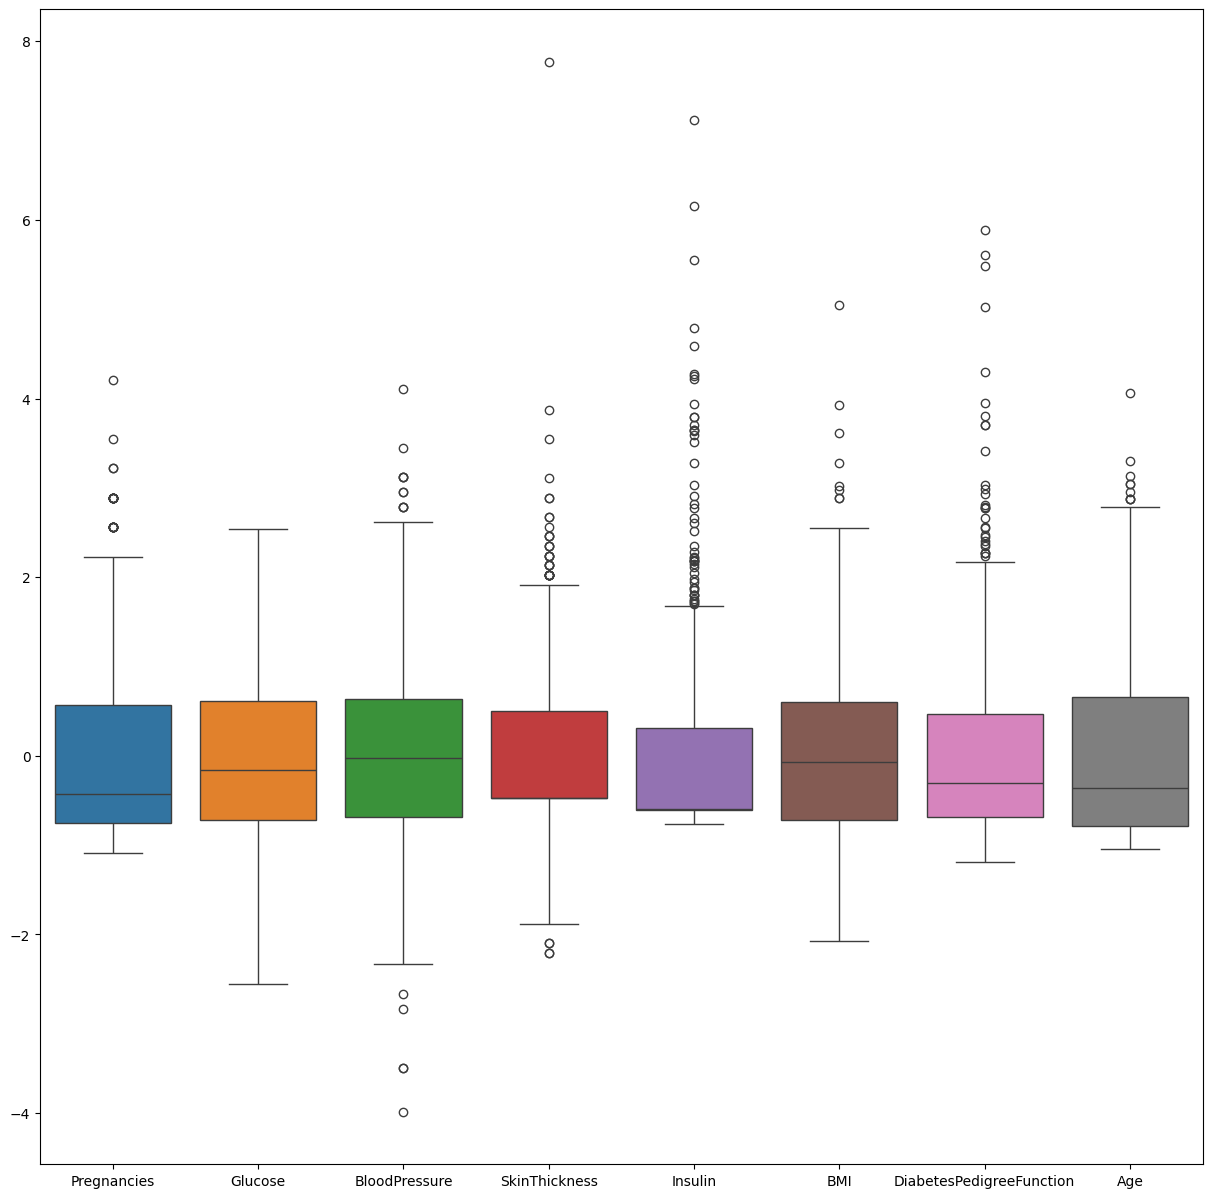

In [131]:
fig, ax = plt.subplots(figsize = (15, 15))
sns.boxplot(data = X_scaled, ax=ax)
plt.savefig('boxPlot.jpg')

Concluding:

Detection of the outliers

Normalization via StandardScaler Form & Why it is important(reduce the biasness in the model)

In [132]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

In [133]:
X_scaled.reset_index(drop=True, inplace=True)
y_outlier_detection.reset_index(drop=True, inplace=True)

In [109]:
# Outlier Treatment for 'Insulin' after scaling
# Due to the persistent presence of outliers in 'Insulin' even after initial imputation and scaling, we apply a quantile-based capping method. Here, values above the 95th percentile are considered outliers and are removed to mitigate their impact on model training.
q = X_scaled['Insulin'].quantile(.95)
mask = X_scaled['Insulin'] < q
dataNew = X_scaled[mask]
y_filtered_for_split = y_outlier_detection[mask] # Ensure y is filtered with the same mask

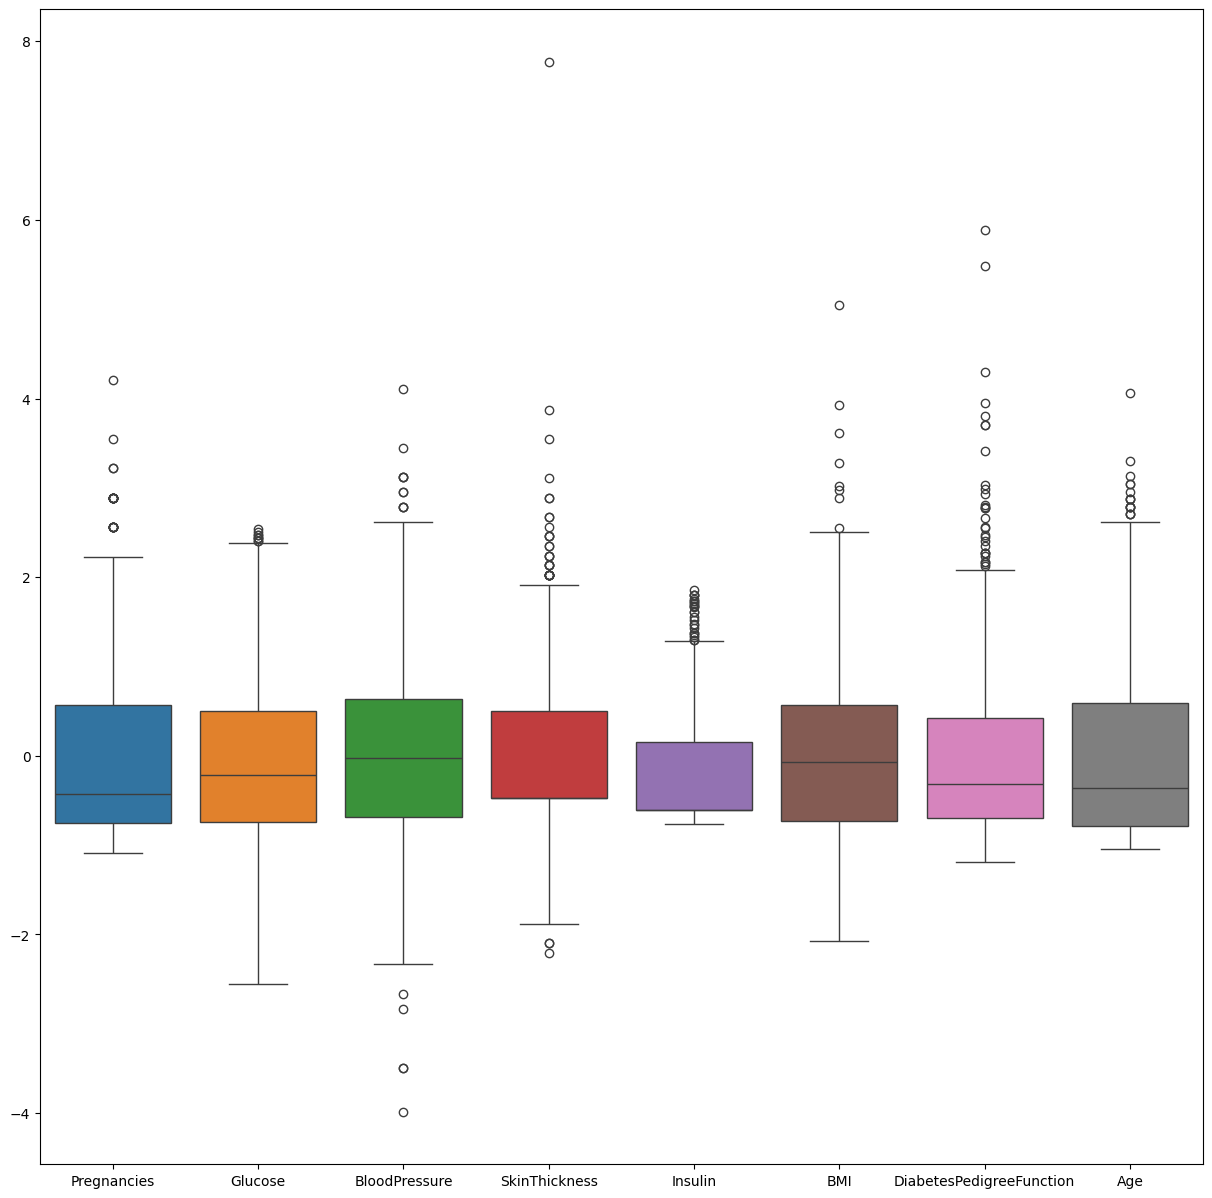

In [110]:
fig, ax = plt.subplots(figsize = (15, 15))
sns.boxplot(data = dataNew, ax=ax)
plt.savefig('boxPlot.jpg')

In [111]:
# Splitting the data into training and testing sets
# This step is essential to evaluate the model's performance on unseen data and prevent overfitting. The data is divided into 67% for training and 33% for testing.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataNew, y_filtered_for_split, test_size=0.33, random_state=42)

In [112]:
X_train.shape

(487, 8)

In [113]:
y_train.value_counts()

,count
Outcome,
0,320
1,167


Data Imbalancing

Oversampling : Minority Class and increase that number to the majority class

Undersampling : Majority class and decrease that number to the minority class

SMOTE : Synthetic data and increase the number of samples to the majority class

In [114]:
# Handling Data Imbalance with SMOTE
# SMOTE (Synthetic Minority Over-sampling Technique) is used to address class imbalance by generating synthetic samples for the minority class. This helps to prevent the model from being biased towards the majority class.
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check resampled class distribution to confirm balancing
print("\nResampled class distribution:")
print(pd.Series(y_train_resampled).value_counts())


Resampled class distribution:
Outcome
1    320
0    320
Name: count, dtype: int64


In [115]:
# Model Training: Logistic Regression
# Logistic Regression is a linear model used for binary classification. It estimates the probability of an instance belonging to a particular class.
from sklearn.linear_model import LogisticRegression
classification = LogisticRegression()
classification.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

In [116]:
y_predictions = classification.predict(X_test)
print(y_predictions)

[1 0 1 0 1 1 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0
 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 1 0 1 1 0
 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 0 0 0
 0 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 1
 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 0 0 1 0 1 0 1 0 1
 0 1 0 1 0 0 0 1 1 0 0 0 1 0 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0
 0 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1]


In [117]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predictions)

0.7302904564315352

Healthcare: Recall is very important metric

In [118]:
from sklearn.metrics import classification_report
target_names = ['Non-Diabetic', 'Diabetic']
print(classification_report(y_test, y_predictions, target_names=target_names))

              precision    recall  f1-score   support

Non-Diabetic       0.84      0.75      0.79       163
    Diabetic       0.57      0.69      0.62        78

    accuracy                           0.73       241
   macro avg       0.70      0.72      0.71       241
weighted avg       0.75      0.73      0.74       241



In [119]:
import pickle
pickle.dump(classification, open("classification_model.pkl", "wb"))

In [120]:
classification_model = pickle.load(open("classification_model.pkl", "rb"))
classification_model.predict(X_test)

array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

In [121]:
# Model Training: K-Nearest Neighbors (KNN)
# KNN is a non-parametric, instance-based learning algorithm. It classifies a data point based on the majority class of its 'k' nearest neighbors in the feature space.
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import classification_report, confusion_matrix
knn = KNeighborsClassifier()

In [122]:
knn.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier()

In [123]:
y_prediction_knn = knn.predict(X_test)
y_prediction_knn

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [124]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_prediction_knn))

Confusion Matrix
[[115  48]
 [ 23  55]]


In [125]:
print("Classification Report")
print(classification_report(y_test, y_prediction_knn))

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.71      0.76       163
           1       0.53      0.71      0.61        78

    accuracy                           0.71       241
   macro avg       0.68      0.71      0.69       241
weighted avg       0.74      0.71      0.71       241



The classification report shows the precision, recall, and F1-score for both 'Non-Diabetic' and 'Diabetic' classes. Recall is particularly important in healthcare for identifying positive cases (Diabetic) to minimize false negatives.

Data Modeling: Implementation of Naive Bayes Classifier

In [126]:
# Model Training: Gaussian Naive Bayes
# Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem, assuming that features are conditionally independent given the class, and that each feature follows a Gaussian (normal) distribution.
from sklearn.naive_bayes import GaussianNB
model_gaussian_naive_bayes = GaussianNB()
model_gaussian_naive_bayes.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [127]:
y_predict_gaussian_naive_bayes = model_gaussian_naive_bayes.predict(X_test)
print(y_predict_gaussian_naive_bayes)

[1 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0
 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 1 0 1 1 0
 0 1 0 1 0 1 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0
 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0
 1 0 0 1 0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1
 1 1 0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0
 0 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 1 0]


In [128]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_predict_gaussian_naive_bayes))

Confusion Matrix
[[122  41]
 [ 26  52]]


In [79]:
# Removed duplicate cell for Confusion Matrix of Gaussian Naive Bayes.

In [129]:
accuracy_score(y_test, y_predict_gaussian_naive_bayes)

0.7219917012448133

In [78]:
# This cell is currently empty, but can be used for further analysis or model comparison with Naive Bayes.

In [ ]:
# This cell is currently empty, but can be used for further analysis or model comparison.